In [1]:
import os
import sys
sys.path.insert(0, os.getcwd())
import sinter
from ldpc.sinter_decoders import SinterBeliefFindDecoder, SinterBpOsdDecoder

from src.cached_bposd_sinter import CachedBpOsdSinterDecoder
from src.stabilizer_code import extract, bb_code
from src.simulate import tostim, detector_error_model_gauge
from src.stim_native_circuit import build_css_stim_circuit, build_bb_stim_tasks_noise

from lib.TrapSIMD.sabre_iontrap import *
from lib.TrapSIMD.grid_iontrap import *

In [2]:
path = "./QEC-Code"

In [3]:
code_name = "BB-code"
stab_fname = os.path.join(path, f"{code_name}.stab")
bb_code(stab_fname)
is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)



(12, 72)


In [4]:
def gen_noise_profile2(p_trans = 2 * 10 ** (-4)):
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        # Scale 2q-gate noise with the swept p_trans so x-axis sweep matters.
        "2q-gate": (18.3 * 10 ** (-4) / (2 * 10 ** (-4))) * p_trans
    }
    return noise_profile 

In [5]:
import time

# Match GenCode style: BB Qiskit schedule -> TrapSIMD grid routing -> Stim + sinter
D = 5
L = 3
CZ = 3
draw_flag = False

noise_list = [2e-4, 1.5e-4, 1e-4]
tasks = []

# BB-code parameters (kept fixed, like a single-distance GenCode run)
ell = 6
m = 6
d_label = ell

# Qiskit iter controls number of syndrome rounds; we also use it as "r" for plotting.
rounds = 4

code_name = "BB-code"
stab_fname = os.path.join(path, f"{code_name}.stab")

t0 = time.time()
# Write .stab for the requested BB size.
bb_code(stab_fname, ell=ell, m=m)
print(f"bb_code: {time.time() - t0:.1f}s")

t1 = time.time()
is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)
print(f"extract(iter={rounds}): {time.time() - t1:.1f}s")

# Deterministic alternative: Z-only syndrome extraction using Stim-native
# BB schedule. We keep the logical-Z observable from the data M results.
z_stabilizers = [s for s in stabilizers if all(gate[1] == "Z" for gate in s["Ctrl"])]

for p in noise_list:
    tp = time.time()
    noise_profile = build_bb_stim_tasks_noise(gen_noise_profile2(p))
    stim_circ = build_css_stim_circuit(
        z_stabilizers,
        noise_profile,
        dataNum,
        rounds=rounds,
        L=L,
        observable_mode="transversal",
    )

    tasks.append(
        sinter.Task(
            circuit=stim_circ,
            json_metadata={"d": d_label, "r": rounds, "p": p},
        )
    )
    print(f"stim-native(z-only) p={p:.1e}: {time.time() - tp:.1f}s")

print(f"built {len(tasks)} tasks in {time.time() - t0:.1f}s")

(12, 72)
bb_code: 0.0s
extract(iter=4): 0.0s
stim-native(z-only) p=2.0e-04: 1.1s
stim-native(z-only) p=1.5e-04: 1.6s
stim-native(z-only) p=1.0e-04: 1.8s
built 3 tasks in 4.5s


In [6]:
# Rebuild tasks for multiple BB distances (to get 3+ curves like GenCode)
import time

tasks = []
ell_list = [4, 5, 7]
code_name = "BB-code"

t0 = time.time()
for ell in ell_list:
    m = ell
    rounds = ell * 3
    stab_fname = os.path.join(path, f"{code_name}-{ell}.stab")

    bb_code(stab_fname, ell=ell, m=m)
    is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)

    z_stabilizers = [s for s in stabilizers if all(gate[1] == "Z" for gate in s["Ctrl"])]

    for p in noise_list:
        noise_profile = build_bb_stim_tasks_noise(gen_noise_profile2(p))
        stim_circ = build_css_stim_circuit(
            z_stabilizers,
            noise_profile,
            dataNum,
            rounds=rounds,
            L=L,
            observable_mode="transversal",
        )

        tasks.append(
            sinter.Task(
                circuit=stim_circ,
                json_metadata={"d": ell, "r": rounds, "p": p},
            )
        )

print(f"rebuilt {len(tasks)} tasks in {time.time() - t0:.1f}s")


KeyError: 3

In [ ]:
tasks[0].circuit

stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
    DEPOLARIZE1(0.00183) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
    R 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107
    DEPOLARIZE1(0.00183) 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107
    TICK
    DEPOLARIZE1(0.00183) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
    CX 3 72 18 72
    DEPOLARIZE2(0.0

In [ ]:
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=["bposd"],
    custom_decoders={"bposd": CachedBpOsdSinterDecoder()},
    max_shots=200_000,
    max_errors=200,
    print_progress=True,
)

Starting 4 workers...
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata   
        2   bposd <1m     199999         199 d=6,r=4,p=0.0002
        2   bposd   ?     200000         200 d=6,r=4,p=0.0001
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata   
        2   bposd <1m     199983         192 d=6,r=4,p=0.0002
        2   bposd <1m     199966         191 d=6,r=4,p=0.0001
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata   
        2   bposd <1m     199966         184 d=6,r=4,p=0.0002
        2   bposd <1m     199966         191 d=6,r=4,p=0.0001
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata   
        2   bposd <1m     199902         152 d=6,r=4,p=0.0002
        2   bposd <1m     199966         191 d=6,r=4,p=0.0001
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata   
        2   bposd <1m     199902         152 d=6,r=4,p=0.0002
        2   bposd <1m     199838        

In [ ]:
# Decoder diagnostics: quick sanity check + tiny speed benchmark
import time

print(f"tasks: {len(tasks)}")
for i, t in enumerate(tasks):
    md = t.json_metadata
    print(f"task[{i}] p={md['p']} r={md['r']} d={md['d']}")

bench_task = tasks[0]

t0 = time.time()
bench_pm = sinter.collect(
    num_workers=1,
    tasks=[bench_task],
    decoders=["bposd"],
    custom_decoders={"bposd": CachedBpOsdSinterDecoder()},
    max_shots=50,
    print_progress=False,
)
print(f"bposd benchmark: {time.time() - t0:.2f}s for 50 shots")
print(bench_pm[0])

tasks: 2
task[0] p=0.0002 r=4 d=6
task[1] p=0.0001 r=4 d=6
bposd benchmark: 0.58s for 50 shots
        50,        16,         0,   0.294,bposd,c766491ac43c6a5a87ed386b010b81934cf5c612396654c440a2f6516a1e7652,"{""d"":6,""p"":0.0002,""r"":4}",


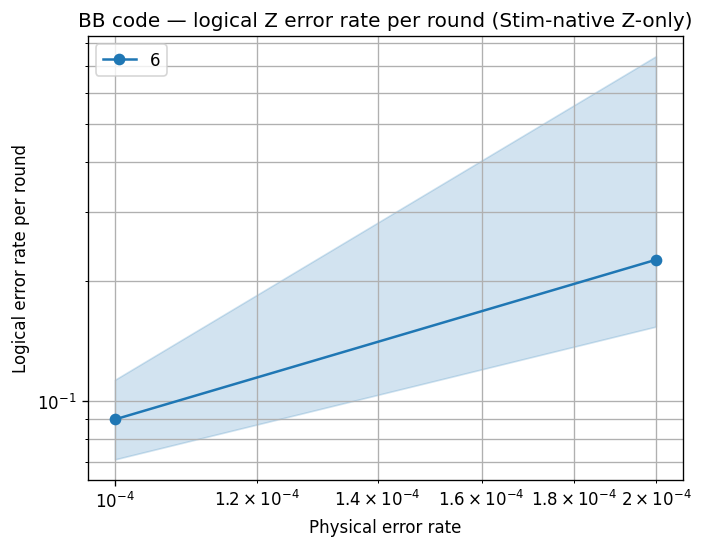

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda st: st.json_metadata["p"],
    failure_units_per_shot_func=lambda st: st.json_metadata["r"],
    group_func=lambda st: st.json_metadata["d"],
)

ax.loglog()
ax.set_title("BB code — logical Z error rate per round (Stim-native Z-only)")
ax.set_xlabel("Physical error rate")
ax.set_ylabel("Logical error rate per round")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)